In [1]:
import numpy as np
import matplotlib.pyplot as plt
import config
config.conf_matplolib()

from waveformtools.waveformtools import get_nr_frame_angles_from_lal
import numpy as np



import numpy as np
import matplotlib.pyplot as plt
import config
config.conf_matplolib()
import os
from tdanalysis.liklihoods.injection import GWTransientTD
from tdanalysis.comparison.combined_discriminator import CombinedChiSquaredRingdown
from pycbc.detector import Detector
from gwpy.timeseries import TimeSeries as gTimeSeries
from waveformtools.waveformtools import compute_masses_from_mass_ratio_and_chirp_mass

import pathlib
home_dir = pathlib.Path.home()
import bilby
from waveformtools.modes_array import ModesArray

/home/vaishakprasad/Projects/custom_libraries/waveformtools/waveformtools


/home/vaishakprasad/Installations/anaconda/envs/gw/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


/home/vaishakprasad/Projects/custom_libraries/spectral/spectral


In [2]:

nr_params = {"mass_ratio": 1.24601646068, "chiA": [0.11052468924950876, 0.14212621057403677, -0.3985805909596128], "chiB": [-0.36095815809820964, 0.3363825711174779, 0.5204313612430432], "adot0": 1.81363257212, "D0": 15.93280029296875, "IDType": "SKS", "t_ref": 434, "omega_ref": 0.014914605479844238, "chiA_ref": [0.084776654441998, 0.17242916669268799, -0.3928392622245707], "chiB_ref": [-0.4409929416135557, 0.21976665946186155, 0.5209991886422614], "massA": 0.55476, "massB": 0.44525, "massC": 0.9525793838912371, "v_kick": [-0.00010154842954459672, -1.3942583595166695e-05, -0.0008306810815515239], "phi_ref": 0.11586358004116531, "chiC": [-0.04608712414595163, 0.05551177686668036, 0.6609041299446653]}

import lal
omega_ref = nr_params["omega_ref"]




chiA_nr = nr_params["chiA_ref"]
chiB_nr = nr_params["chiB_ref"]

spin1x, spin1y, spin1z = chiA_nr
spin2x, spin2y, spin2z = chiB_nr

In [3]:
wf_path = "/home/vaishakprasad/Projects/ligo/S230814ah/data/rhOverM_rhOverM_Extrapolated_N3_CoM_Lev4.h5"
wfm = ModesArray(label='R114Sur',
                 spin_weight=-2, 
                 data_dir="/home/vaishakprasad/Projects/ligo/S230814ah/data",
                 file_name="rhOverM_rhOverM_Extrapolated_N3_CoM_Lev4.h5",
                 )
wfm.load_modes(ftype="SpEC",
               extrap_order=None)

Loading SpEC data NNone
['History.txt', 'Y_l2_m-1.dat', 'Y_l2_m-2.dat', 'Y_l2_m0.dat', 'Y_l2_m1.dat', 'Y_l2_m2.dat', 'Y_l3_m-1.dat', 'Y_l3_m-2.dat', 'Y_l3_m-3.dat', 'Y_l3_m0.dat', 'Y_l3_m1.dat', 'Y_l3_m2.dat', 'Y_l3_m3.dat', 'Y_l4_m-1.dat', 'Y_l4_m-2.dat', 'Y_l4_m-3.dat', 'Y_l4_m-4.dat', 'Y_l4_m0.dat', 'Y_l4_m1.dat', 'Y_l4_m2.dat', 'Y_l4_m3.dat', 'Y_l4_m4.dat', 'Y_l5_m-1.dat', 'Y_l5_m-2.dat', 'Y_l5_m-3.dat', 'Y_l5_m-4.dat', 'Y_l5_m-5.dat', 'Y_l5_m0.dat', 'Y_l5_m1.dat', 'Y_l5_m2.dat', 'Y_l5_m3.dat', 'Y_l5_m4.dat', 'Y_l5_m5.dat', 'Y_l6_m-1.dat', 'Y_l6_m-2.dat', 'Y_l6_m-3.dat', 'Y_l6_m-4.dat', 'Y_l6_m-5.dat', 'Y_l6_m-6.dat', 'Y_l6_m0.dat', 'Y_l6_m1.dat', 'Y_l6_m2.dat', 'Y_l6_m3.dat', 'Y_l6_m4.dat', 'Y_l6_m5.dat', 'Y_l6_m6.dat', 'Y_l7_m-1.dat', 'Y_l7_m-2.dat', 'Y_l7_m-3.dat', 'Y_l7_m-4.dat', 'Y_l7_m-5.dat', 'Y_l7_m-6.dat', 'Y_l7_m-7.dat', 'Y_l7_m0.dat', 'Y_l7_m1.dat', 'Y_l7_m2.dat', 'Y_l7_m3.dat', 'Y_l7_m4.dat', 'Y_l7_m5.dat', 'Y_l7_m6.dat', 'Y_l7_m7.dat', 'Y_l8_m-1.dat', 'Y_l8_m-2.dat', '

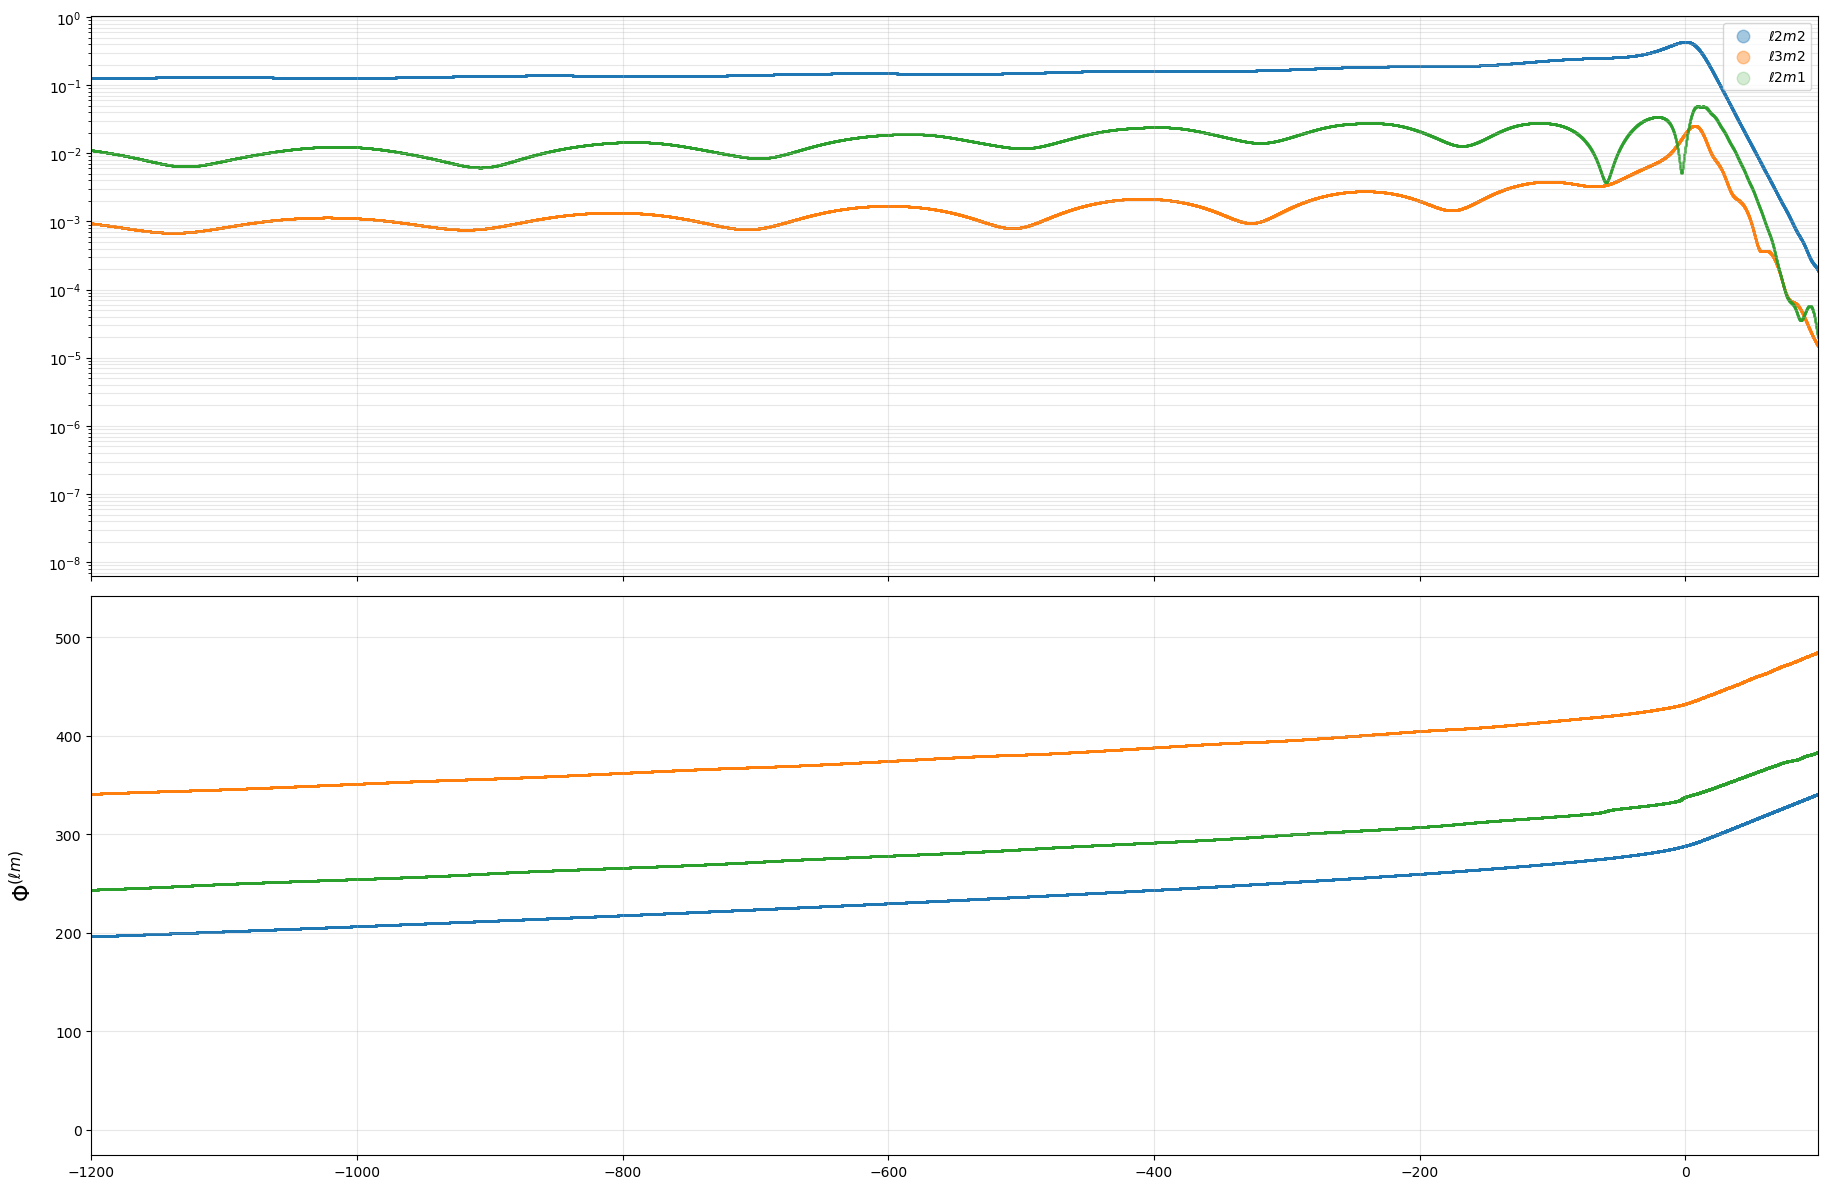

In [19]:
fig, ax = wfm.plot_strongest_modes(nmodes=3)

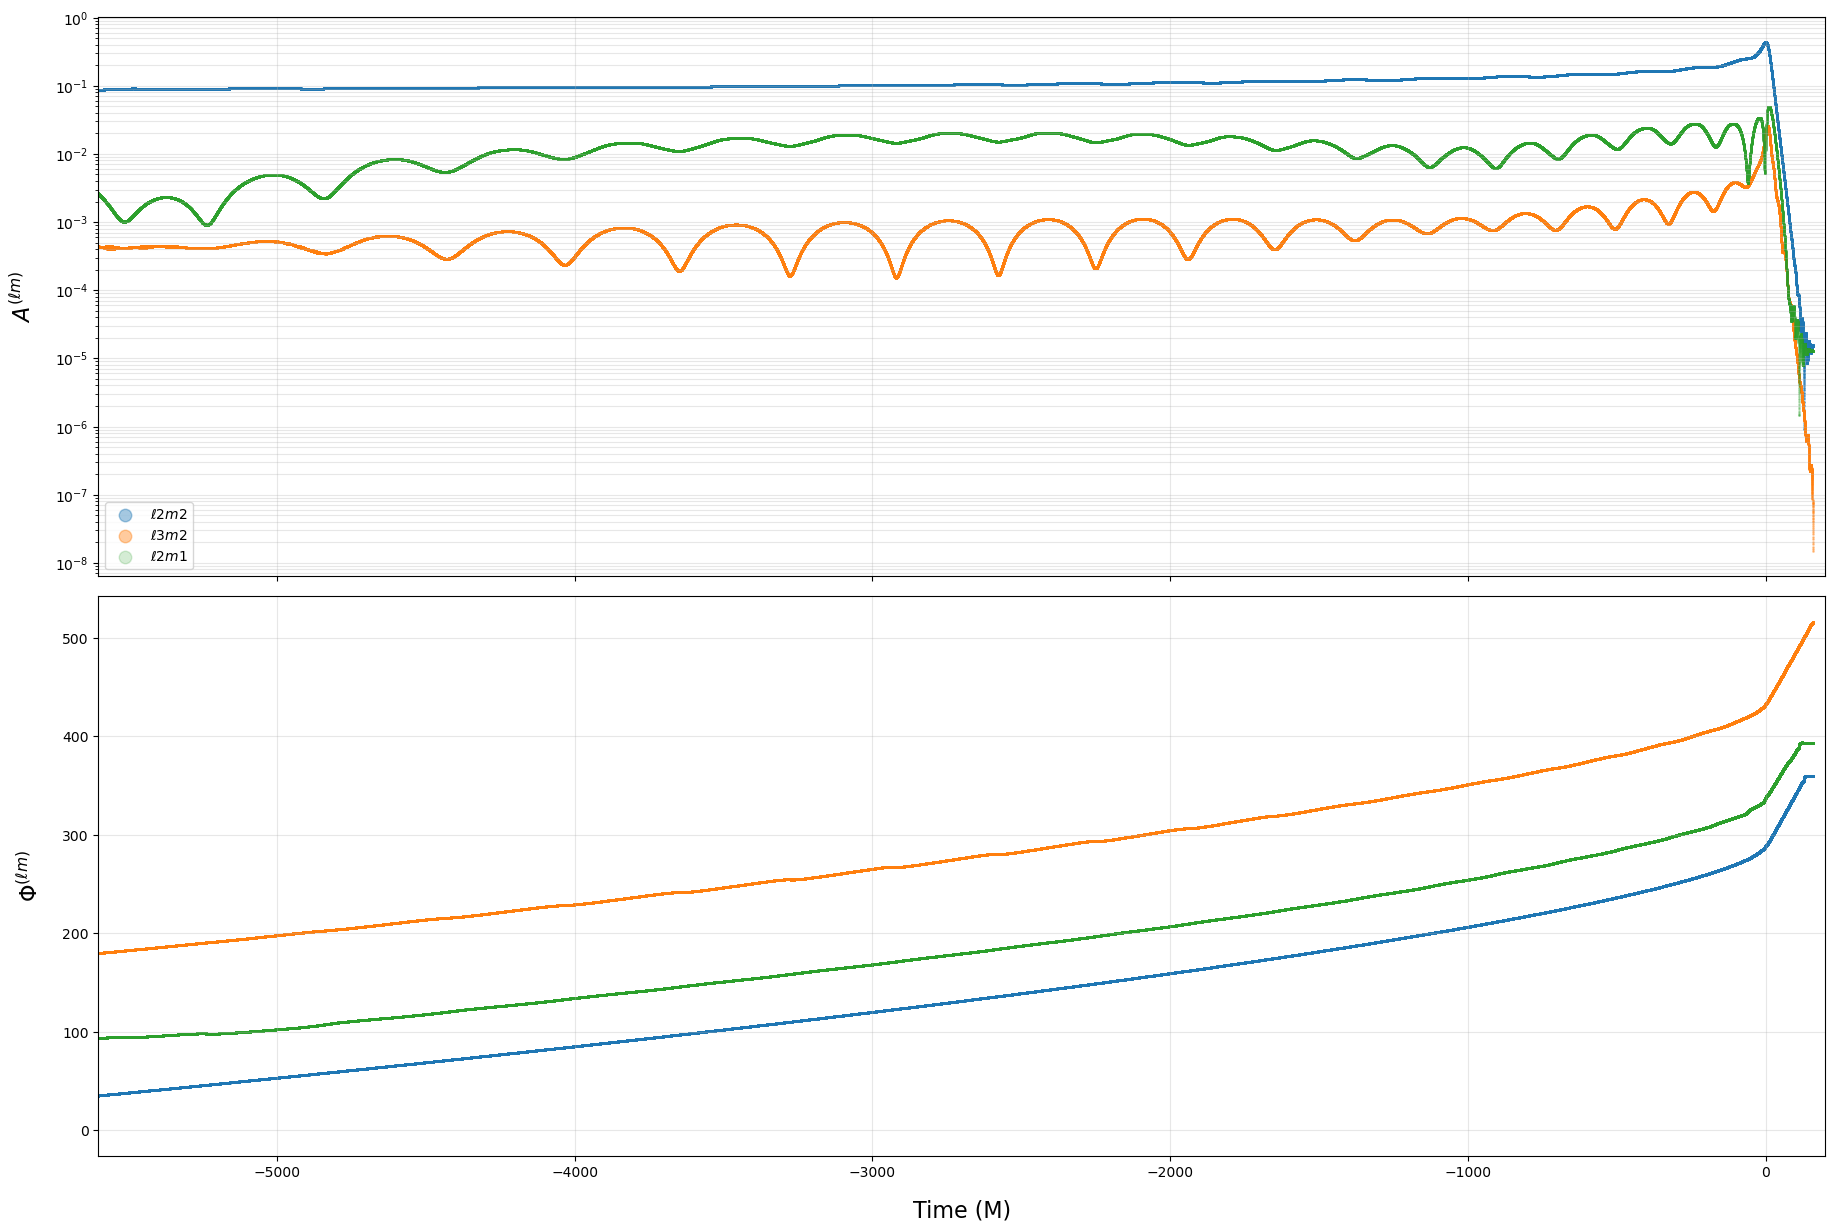

In [20]:
ax[1].set_xlim(-5600, 200)
ax[0].set_ylabel(r"$A^{(\ell m)}$")
ax[1].set_xlabel(r"Time (M)")
fig

In [154]:
from waveformtools.waveformtools import compute_chi_eff_from_masses_and_spins, compute_chi_prec_from_masses_and_spins

In [155]:

# %%
L1_channel = "L1:GDS-CALIB_STRAIN_CLEAN"
H1_channel = "H1:GDS-CALIB_STRAIN_CLEAN"
trigger_time = 1376089759.805


# %%
signal_file = home_dir/"Projects/ligo/S230814ah/data/S230814ah_3s.gwf"

if not os.path.exists(signal_file):
    lsignal = gTimeSeries.get(L1_channel, start_gps, end_gps, verbose=True)
    lsignal = lsignal.resample(4096)
    #lnoise2 = lnoise[100:12388]
    lsignal.write(signal_file)
else:
    lsignal = gTimeSeries.read(signal_file, L1_channel)

# %%
#if not os.path.exists("../data/invLij_S230814ah.npy"):
if not os.path.exists(home_dir/"Projects/ligo/S230814ah/data/invLij_welch_median_mean.npy"):
    #invLij = np.load("../data/invLij_S230814ah.npy")
    raise NotImplementedError
    #Cij = np.load("/home/vaishakprasad/Projects/custom_libraries/tdanalysis/dev/scripts/Cij_gpsT1420878141_R512_D3_S4096_A3_N512.npy")
    #Lij = np.linalg.cholesky(Cij)
    #invLij = np.linalg.inv(Lij)
    #np.save("invLij.npy", invLij)
else:
    invLij = np.load(home_dir/"Projects/ligo/S230814ah/data/invLij_welch_median_mean.npy")



ifo = Detector('L1')

# %%
# NRSur values
mass_ratio= 0.802557615852963
chirp_mass= 28.408601651547638
spin1x0 =    0.11052468924950876
spin1y0 =    0.14212621057403677
spin1z0 =    -0.3985805909596128
spin2x0 =    -0.36095815809820964
spin2y0 =    0.3363825711174779
spin2z0 =    0.5204313612430432
coa_phase = 1.2920004923502657
distance = 382.8777908017761
inclination =2.243083173204375
ra     =    1.291251275992068
dec    =    -0.356079570702216
psi    =    3.1266506704704886
geocent_time =    1376089759.787524


chiA0 = [spin1x0, spin1y0, spin1z0]
chiB0 = [spin2x0, spin2y0, spin2z0]

delta_t = ifo.time_delay_from_earth_center(ra, dec, geocent_time)
t_coal = geocent_time + delta_t
f_ref = omega_ref/(2*np.pi*lal.MTSUN_SI*(mass1+mass2))

chi_eff = compute_chi_eff_from_masses_and_spins(chiA_nr, chiB_nr, mass_ratio)
chi_prec = compute_chi_prec_from_masses_and_spins(chiA_nr, chiB_nr, mass_ratio)
chi_eff0 = compute_chi_eff_from_masses_and_spins(chiA0, chiB0, mass_ratio)
chi_prec0 = compute_chi_prec_from_masses_and_spins(chiA0, chiB0, mass_ratio)


In [156]:
chi_eff, chi_eff0

(0.11412841682762279, 0.11125717739809002)

In [157]:
chi_prec, chi_prec0

(0.6334550940882618, 0.634331025354798)

In [ ]:


injection_parameters_sur = {
    'mass_ratio': mass_ratio,
    'chirp_mass': chirp_mass,
    'spin1x' :    spin1x,
    'spin1y' :    spin1y,
    'spin1z' :    spin1z,
    'spin2x' :    spin2x,
    'spin2y' :    spin2y,
    'spin2z' :    spin2z,
    'coa_phase' : coa_phase,
    'distance' : distance,
    'inclination' : inclination,
    'ra'     :    ra,
    'dec'    :    dec,
    'psi'    :    psi,
    't_coal' : t_coal,
    
}

###########################################
# dummy
parameter_priors_dict = {
    'mass_ratio': [0.1, 1],
    'chirp_mass': [chirp_mass, chirp_mass],
    'spin1x' : [spin1x, spin1x],
    'spin1y' : [spin1y, spin1y],
    'spin1z' : [spin1z, spin1z],
    'spin2x' : [spin2x, spin2x],
    'spin2y' : [spin2y, spin2y],
    'spin2z' : [spin2z, spin2z],
    'coa_phase' : [coa_phase, coa_phase],
    'distance' : [distance, distance],
    'inclination' : [inclination, inclination],
    'ra'     : [ra, ra],
    'dec'    : [dec, dec],
    'psi'    : [psi, psi],
    't_coal' : [t_coal, t_coal],
}

sampling_parameters = {}
for key in injection_parameters_sur.keys():
    sampling_parameters.update({key : 1})


gmodel_sur = GWTransientTD(
                            xdata=lsignal.times.value,
                            ydata=np.array(lsignal),
                            initial_guess=[3, 2],
                            parameter_priors_dict=parameter_priors_dict,
                            truths=None,
                            detector='L1',
                            approximant='NRSur7dq4',
                            #approximant='IMRPhenomXPHM',
                            invLij=invLij,
                            injection_parameters=injection_parameters_sur,
                            #sampling_parameters=['mass_ratio', 'chirp_mass', 'distance']
                            sampling_parameters=list(injection_parameters_sur.keys()),
                            f_lower=0,
                            f_ref=20
                          )


gmodel_imr = GWTransientTD(
                            xdata=lsignal.times.value,
                            ydata=np.array(lsignal),
                            initial_guess=[3, 2],
                            parameter_priors_dict=parameter_priors_dict,
                            truths=None,
                            detector='L1',
                            approximant='IMRPhenomXPHM',
                            #approximant='IMRPhenomXPHM',
                            invLij=invLij,
                            injection_parameters=injection_parameters_sur,
                            #sampling_parameters=['mass_ratio', 'chirp_mass', 'distance']
                            sampling_parameters=list(injection_parameters_sur.keys()),
                            f_lower=f_ref,
                            f_ref=f_ref
                          )


gmodel_eob = GWTransientTD(
                            xdata=lsignal.times.value,
                            ydata=np.array(lsignal),
                            initial_guess=[3, 2],
                            parameter_priors_dict=parameter_priors_dict,
                            truths=None,
                            detector='L1',
                            approximant='SEOBNRv5PHM',
                            #approximant='IMRPhenomXPHM',
                            invLij=invLij,
                            injection_parameters=injection_parameters_sur,
                            #sampling_parameters=['mass_ratio', 'chirp_mass', 'distance']
                            sampling_parameters=list(injection_parameters_sur.keys()),
                            f_lower=f_ref,
                            f_ref=f_ref
                          )

pars = list(injection_parameters_sur.values())
all_parameters_dict = gmodel_sur.get_all_parameters_dict(pars)



mass1, mass2 = compute_masses_from_mass_ratio_and_chirp_mass(all_parameters_dict['mass_ratio'], 
                                                                all_parameters_dict['chirp_mass'])

hp1, hc1 = gmodel_sur.get_td_waveform(approximant=gmodel_sur.approximant,
                                 f_lower = gmodel_sur.f_lower,
                                 f_ref = gmodel_sur.f_ref,
                                 delta_t = gmodel_sur.delta_t,
                                 mass1=mass1,
                                 mass2=mass2,
                                 **all_parameters_dict
                                 )



hp2, hc2 = gmodel_imr.get_td_waveform(approximant=gmodel_imr.approximant,
                                 f_lower = gmodel_imr.f_lower,
                                 f_ref = gmodel_imr.f_ref,
                                 delta_t = gmodel_imr.delta_t,
                                 mass1=mass1,
                                 mass2=mass2,
                                 **all_parameters_dict
                                 )



hp3, hc3 = gmodel_eob.get_td_waveform(approximant=gmodel_eob.approximant,
                                 f_lower = gmodel_eob.f_lower,
                                 f_ref = gmodel_eob.f_ref,
                                 delta_t = gmodel_eob.delta_t,
                                 mass1=mass1,
                                 mass2=mass2,
                                 **all_parameters_dict
                                 )


imr_times = np.arange(len(hp2))/4096

imr_argmax = np.argmax(abs(hp2-1j*hc2))
imr_tpeak = imr_times[imr_argmax]
imr_times -= imr_tpeak

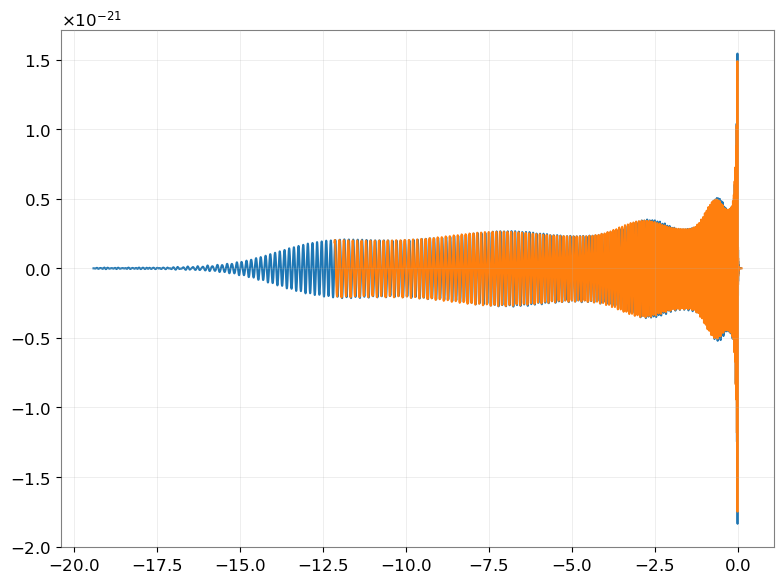

In [ ]:
#plt.plot(times, hp)
#plt.plot(hp1.sample_times, hp1)
plt.plot(imr_times, hp2)
plt.plot(hp3.sample_times, hp3)
plt.show()

In [121]:
np.diff(phi_sur)*4096/(2*np.pi)

array([ 15.86275789,  15.858636  ,  15.85634454, ...,
       502.63718574, 302.39358948, 197.58515826])

In [86]:
len(hp2), len(hp3)

(20056, 10174)

In [84]:
gmodel_imr.xdata

array([1.37608976e+09, 1.37608976e+09, 1.37608976e+09, ...,
       1.37608976e+09, 1.37608976e+09, 1.37608976e+09])

In [17]:
phi1 = np.unwrap(np.angle(hp1-1j*hc1))

In [130]:
from waveformtools.waveformtools import xtract_camp_phase



In [131]:
angles = get_nr_frame_angles_from_lal(inclination=inclination, phi_ref=coa_phase)
angles

{'theta': 2.243083173204375,
 'psi': 0.2787958344446306,
 'alpha': 3.141592638688632}

In [132]:
angles0 = get_nr_frame_angles_from_lal(inclination=0, phi_ref=2)
angles0

{'theta': 0.0, 'psi': 0.5, 'alpha': 2.21238898038469}

In [133]:
inclination, coa_phase

(2.243083173204375, 1.2920004923502657)

/home/vaishakprasad/Projects/custom_libraries/spectral/spectral


Loading SpEC data NNone
['History.txt', 'Y_l2_m-1.dat', 'Y_l2_m-2.dat', 'Y_l2_m0.dat', 'Y_l2_m1.dat', 'Y_l2_m2.dat', 'Y_l3_m-1.dat', 'Y_l3_m-2.dat', 'Y_l3_m-3.dat', 'Y_l3_m0.dat', 'Y_l3_m1.dat', 'Y_l3_m2.dat', 'Y_l3_m3.dat', 'Y_l4_m-1.dat', 'Y_l4_m-2.dat', 'Y_l4_m-3.dat', 'Y_l4_m-4.dat', 'Y_l4_m0.dat', 'Y_l4_m1.dat', 'Y_l4_m2.dat', 'Y_l4_m3.dat', 'Y_l4_m4.dat', 'Y_l5_m-1.dat', 'Y_l5_m-2.dat', 'Y_l5_m-3.dat', 'Y_l5_m-4.dat', 'Y_l5_m-5.dat', 'Y_l5_m0.dat', 'Y_l5_m1.dat', 'Y_l5_m2.dat', 'Y_l5_m3.dat', 'Y_l5_m4.dat', 'Y_l5_m5.dat', 'Y_l6_m-1.dat', 'Y_l6_m-2.dat', 'Y_l6_m-3.dat', 'Y_l6_m-4.dat', 'Y_l6_m-5.dat', 'Y_l6_m-6.dat', 'Y_l6_m0.dat', 'Y_l6_m1.dat', 'Y_l6_m2.dat', 'Y_l6_m3.dat', 'Y_l6_m4.dat', 'Y_l6_m5.dat', 'Y_l6_m6.dat', 'Y_l7_m-1.dat', 'Y_l7_m-2.dat', 'Y_l7_m-3.dat', 'Y_l7_m-4.dat', 'Y_l7_m-5.dat', 'Y_l7_m-6.dat', 'Y_l7_m-7.dat', 'Y_l7_m0.dat', 'Y_l7_m1.dat', 'Y_l7_m2.dat', 'Y_l7_m3.dat', 'Y_l7_m4.dat', 'Y_l7_m5.dat', 'Y_l7_m6.dat', 'Y_l7_m7.dat', 'Y_l8_m-1.dat', 'Y_l8_m-2.dat', '

In [11]:
wfm.modes_list

[[2, [-2, -1, 0, 1, 2]],
 [3, [-3, -2, -1, 0, 1, 2, 3]],
 [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]],
 [5, [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]],
 [6, [-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]],
 [7, [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]],
 [8, [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]]]

In [12]:
wfm.mode(2, 2)

array([ 1.09392470e-04-4.53275792e-04j,
        1.09424789e-04-4.53433197e-04j,
        1.09457148e-04-4.53590638e-04j, ...,
       -4.12387620e-07-1.52108258e-05j,
       -4.29752932e-07-1.51943151e-05j,
       -4.46721233e-07-1.51775079e-05j])

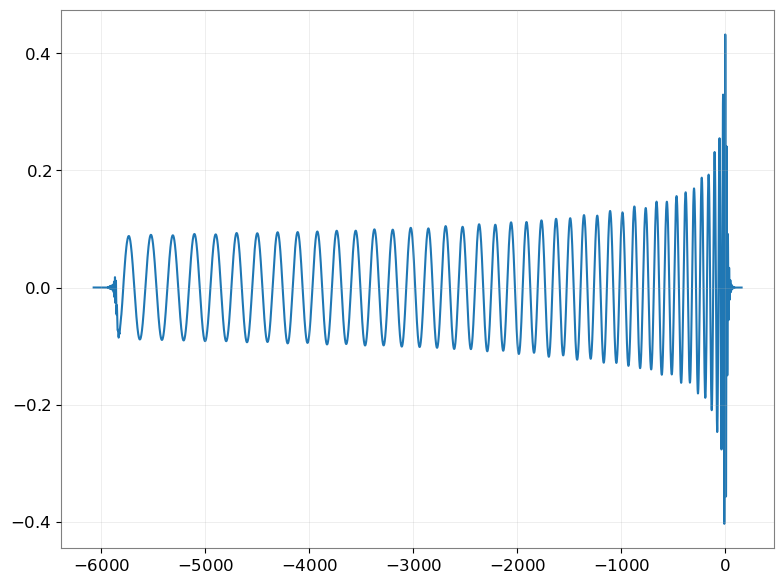

In [13]:
plt.plot(wfm.time_axis, wfm.mode(2,2).real)

In [14]:
times, hp, hc = wfm.to_td_waveform(inclination=inclination, phi_ref=coa_phase, distance=distance, delta_t=1/4096, Mtotal=mass1+mass2)

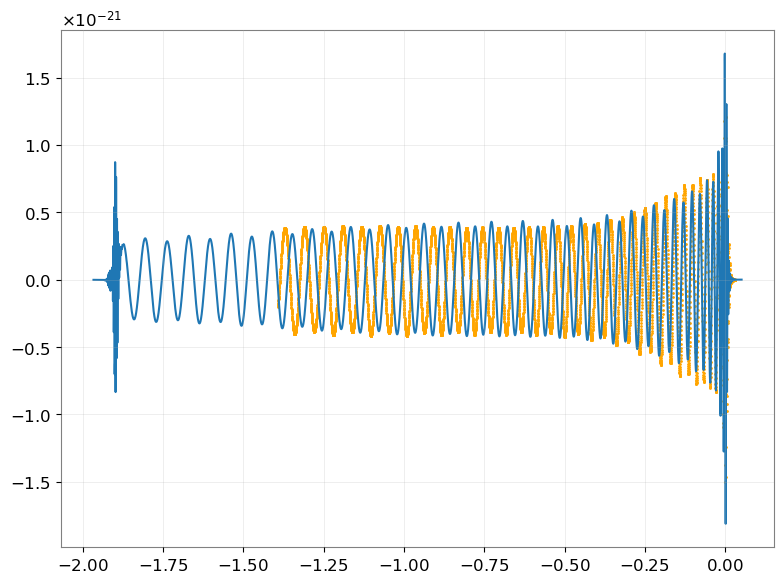

In [140]:
plt.plot(times, hc)
plt.scatter(hp1.sample_times, hp1, s=1, c='orange')
plt.show()

In [134]:
argmax_nr = np.argmax(abs(hp + 1j*hc))
argmax_sur = np.argmax(abs(hp1 - 1j*hc1))
argmax_imr = np.argmax(abs(hp2 + 1j*hc2))
argmax_eob = np.argmax(abs(hp3 - 1j*hc3))

dt_sur = hp1.sample_times[argmax_sur]
dt_imr = imr_times[argmax_imr]
dt_nr = times[argmax_nr]
dt_eob = hp3.sample_times[argmax_eob]

N = int(1.25*4096)

hp_nr = hp[argmax_nr-N:argmax_nr+125]
hc_nr = hc[argmax_nr-N:argmax_nr+125]

hp_sur = hp1[argmax_sur-N:argmax_sur+125]
hc_sur = hc1[argmax_sur-N:argmax_sur+125]

hp_imr = hp2[argmax_imr-N:argmax_imr+125]
hc_imr = hc2[argmax_imr-N:argmax_imr+125]

hp_eob = hp3[argmax_eob-N:argmax_eob+125]
hc_eob = hc3[argmax_eob-N:argmax_eob+125]

A_nr, phi_nr = xtract_camp_phase(hp_nr, hc_nr)
A_sur, phi_sur = xtract_camp_phase(hp_sur, -hc_sur)
A_imr, phi_imr = xtract_camp_phase(hp_imr, -hc_imr)
A_eob, phi_eob = xtract_camp_phase(hp_eob, -hc_eob)

times_nr = times[argmax_nr-N:argmax_nr+125] - dt_nr
times_sur = hp1.sample_times[argmax_sur-N:argmax_sur+125] - dt_sur
times_imr = imr_times[argmax_imr-N:argmax_imr+125] - dt_imr
times_eob = hp3.sample_times[argmax_eob-N:argmax_eob+125] - dt_eob


phi_diff_sur = np.mean( (-phi_nr + phi_sur)[:10])
phi_diff_imr = np.mean( (-phi_nr + phi_imr)[:10])
phi_diff_eob = np.mean( (-phi_nr + phi_eob)[:10])


phi_sur -= phi_diff_sur
phi_imr -= phi_diff_imr
phi_eob -= phi_diff_eob

In [41]:
omega = np.diff(phi0)*4096

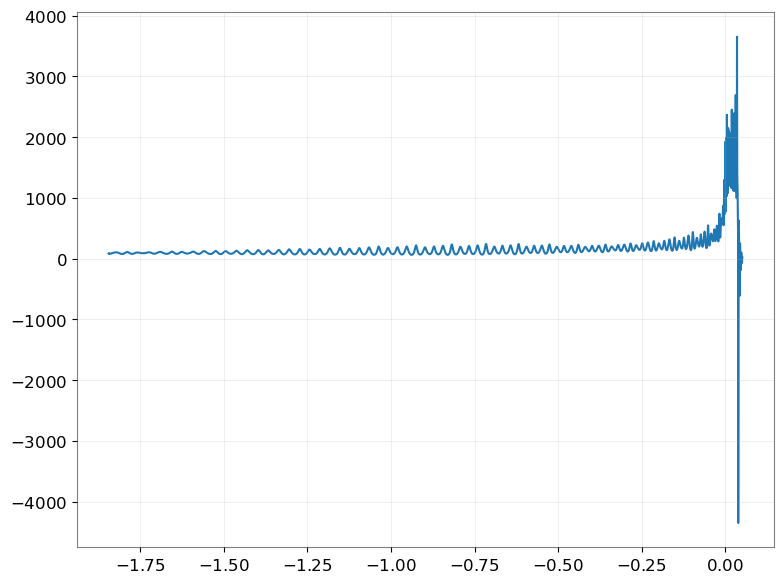

In [49]:
plt.plot(times[500:-1], omega[500:])

In [53]:
omega[500]/(2*np.pi)

13.26699392475435

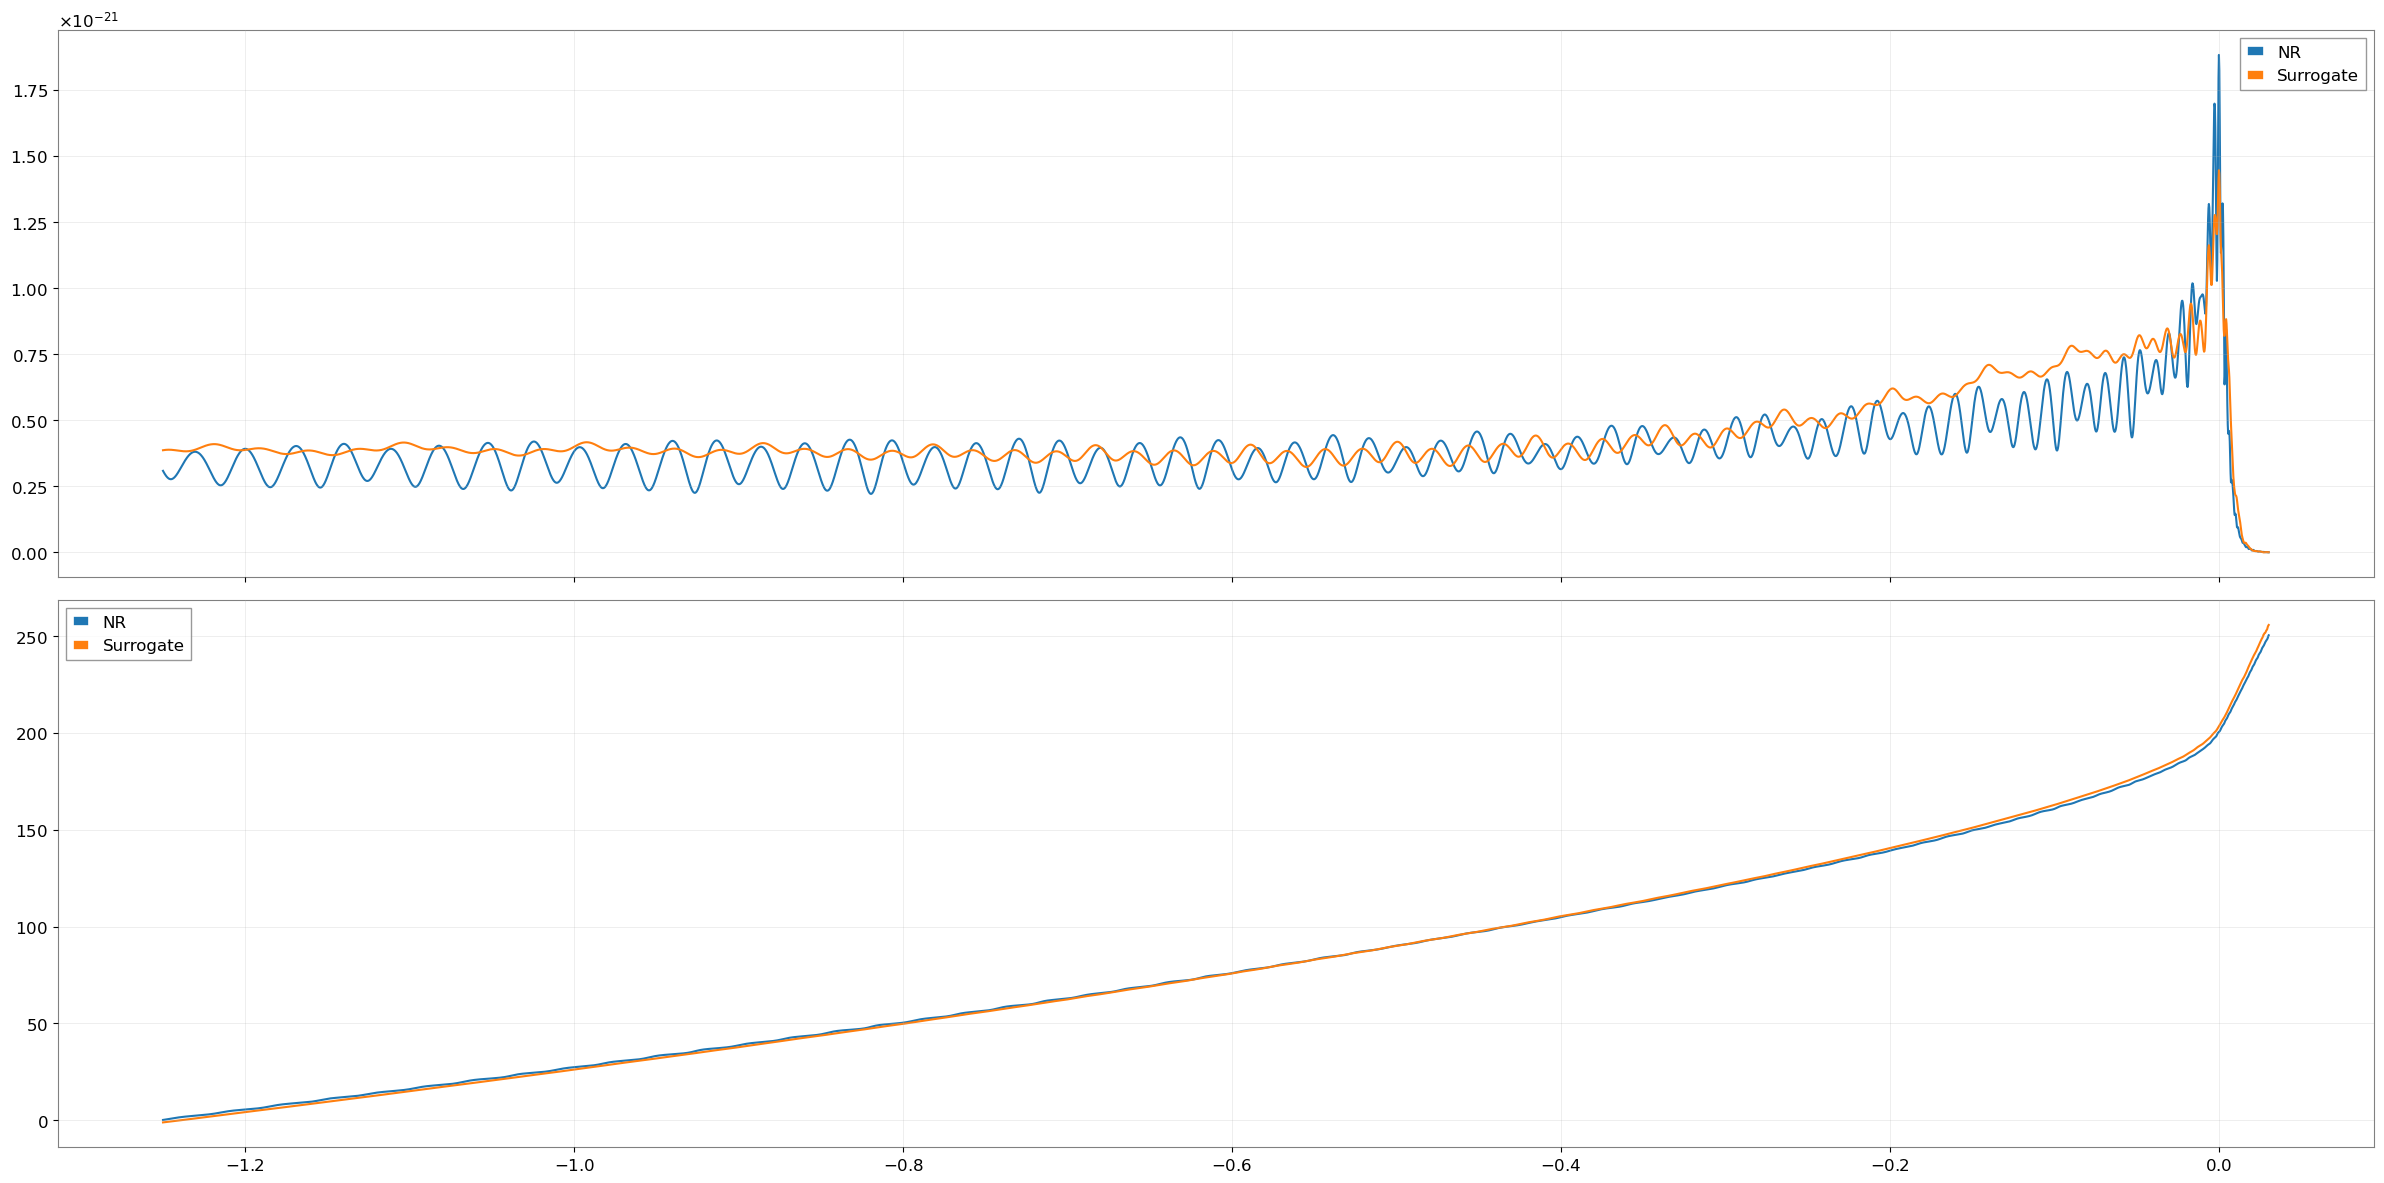

In [94]:
#A0, phi0 = xtract_camp_phase(hp, hc)
fig, ax = plt.subplots(nrows=2, figsize=(24, 12), sharex=True)

ax[0].plot(times_nr, A_nr, label='NR')
ax[0].plot(times_sur, A_sur, label='Surrogate')
ax[0].legend()

ax[1].plot(times_nr, phi_nr+phi_diff, label='NR')
ax[1].plot(times_sur, phi_sur, label='Surrogate')
ax[1].legend()
plt.show()

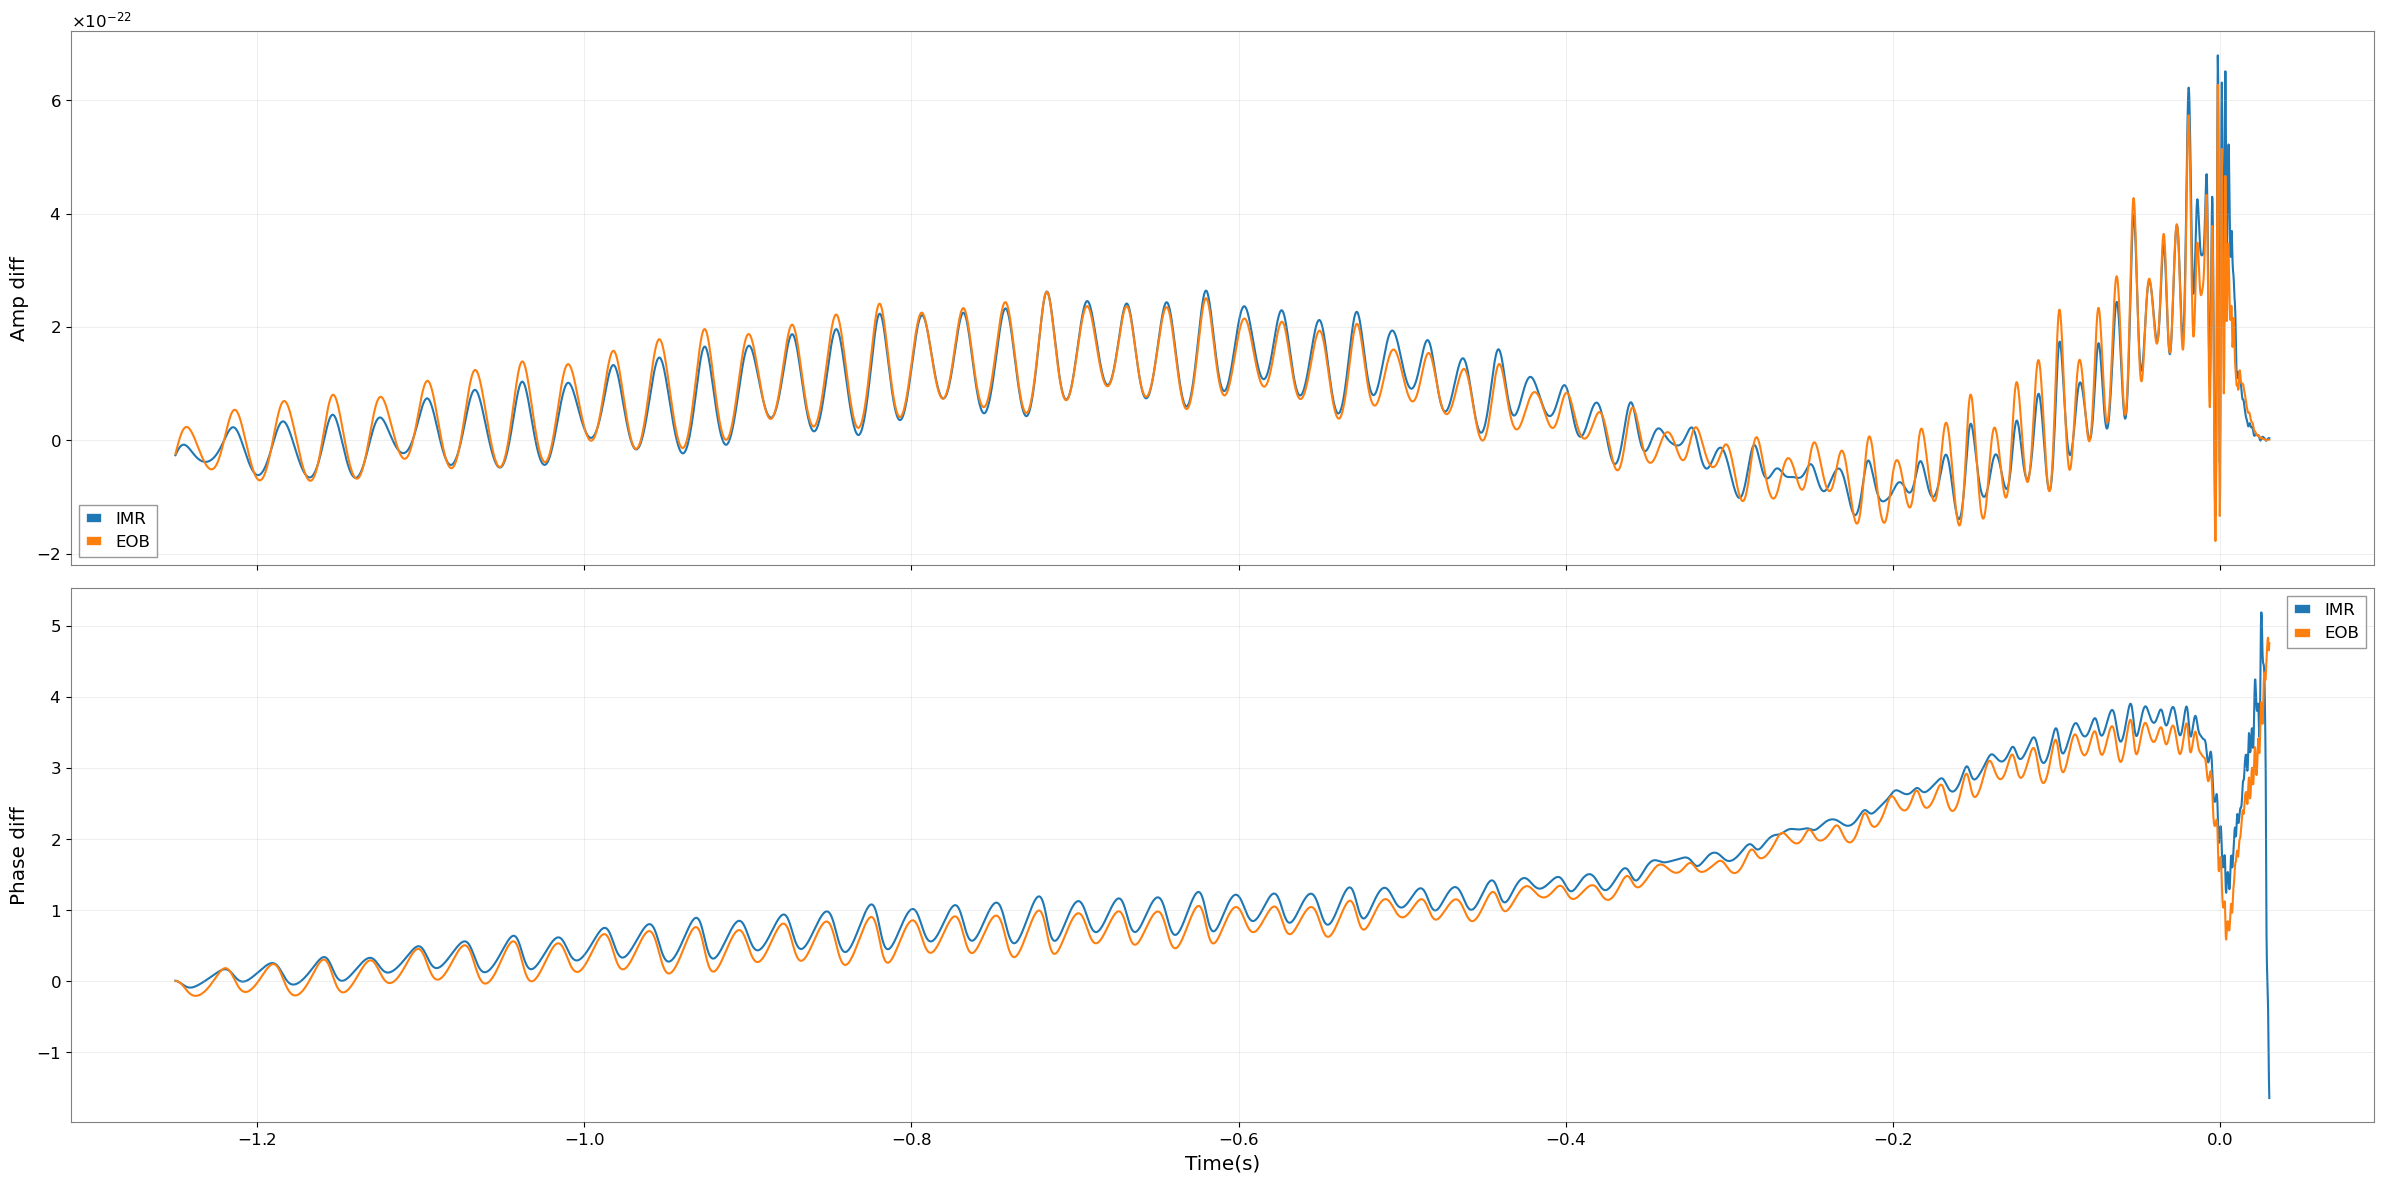

In [139]:
#A0, phi0 = xtract_camp_phase(hp, hc)
fig, ax = plt.subplots(nrows=2, figsize=(24, 12), sharex=True)

#ax[0].plot(times_nr, A_sur-A_nr, label='Surrogate')
ax[0].plot(times_sur, A_imr-A_nr, label='IMR')
ax[0].plot(times_sur, A_eob-A_nr, label='EOB')
ax[0].set_ylabel("Amp diff")
ax[0].legend(loc=3)

#ax[1].plot(times_nr, phi_sur-phi_nr, label='Surrogate')
ax[1].plot(times_sur, phi_imr- phi_nr, label='IMR')
ax[1].plot(times_sur, phi_eob- phi_nr, label='EOB')
ax[1].legend()
ax[1].set_xlabel("Time(s)")
ax[1].set_ylabel("Phase diff")
plt.show()

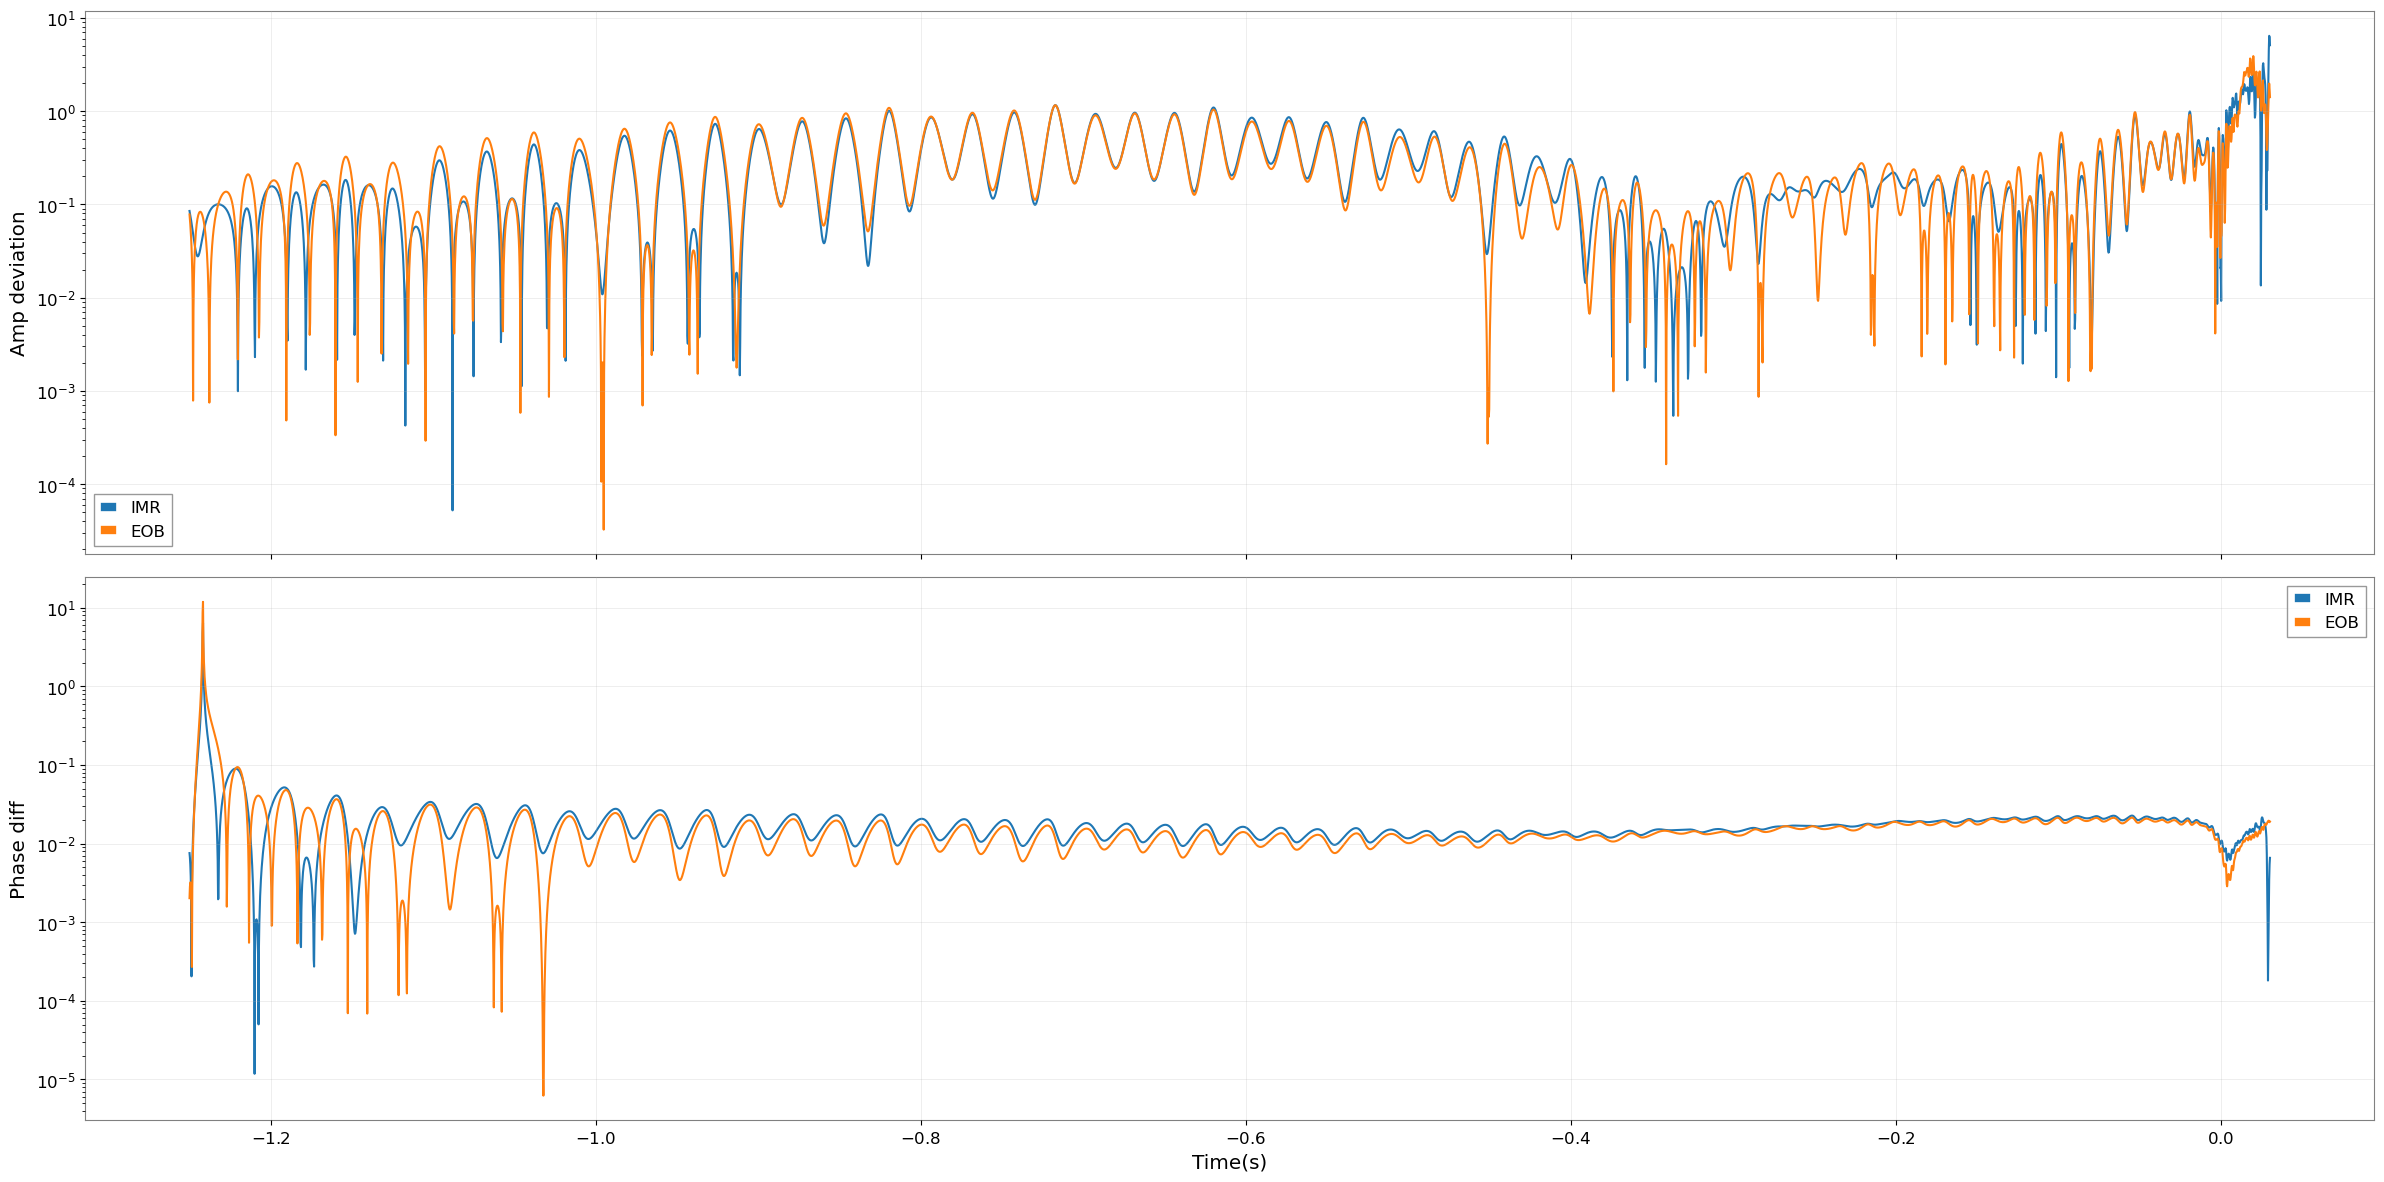

In [142]:
#A0, phi0 = xtract_camp_phase(hp, hc)
fig, ax = plt.subplots(nrows=2, figsize=(24, 12), sharex=True)
ax[0].set_yscale('log')
ax[1].set_yscale('log')

#ax[0].plot(times_nr, A_sur-A_nr, label='Surrogate')
ax[0].plot(times_sur, abs(A_imr/A_nr -1), label='IMR')
ax[0].plot(times_sur, abs(A_eob/A_nr -1), label='EOB')
ax[0].set_ylabel("Amp deviation")
ax[0].legend(loc=3)

#ax[1].plot(times_nr, phi_sur-phi_nr, label='Surrogate')
ax[1].plot(times_sur, abs(phi_imr/phi_nr-1), label='IMR')
ax[1].plot(times_sur, abs(phi_eob/phi_nr-1), label='EOB')
ax[1].legend()
ax[1].set_xlabel("Time(s)")
ax[1].set_ylabel("Phase diff")
plt.show()

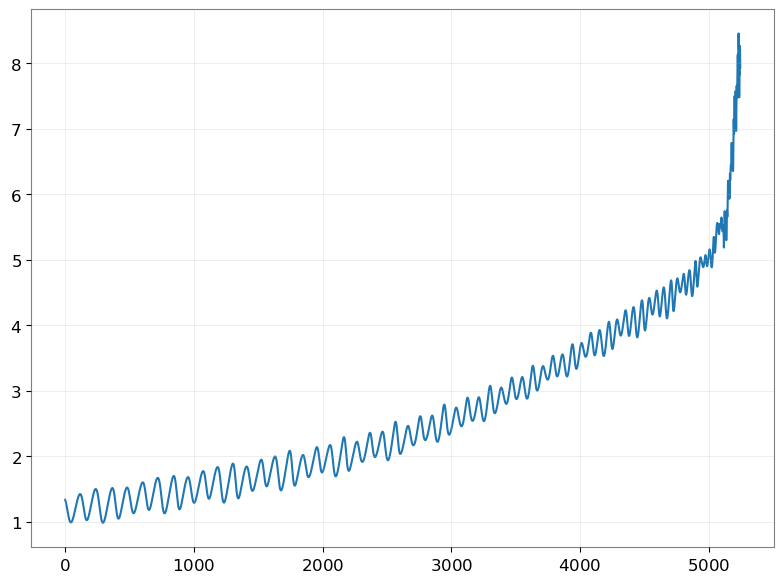

In [70]:
plt.plot(-phi_nr + phi_sur)

/home/vaishakprasad/Projects/custom_libraries/waveformtools/waveformtools/compare.py:147: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


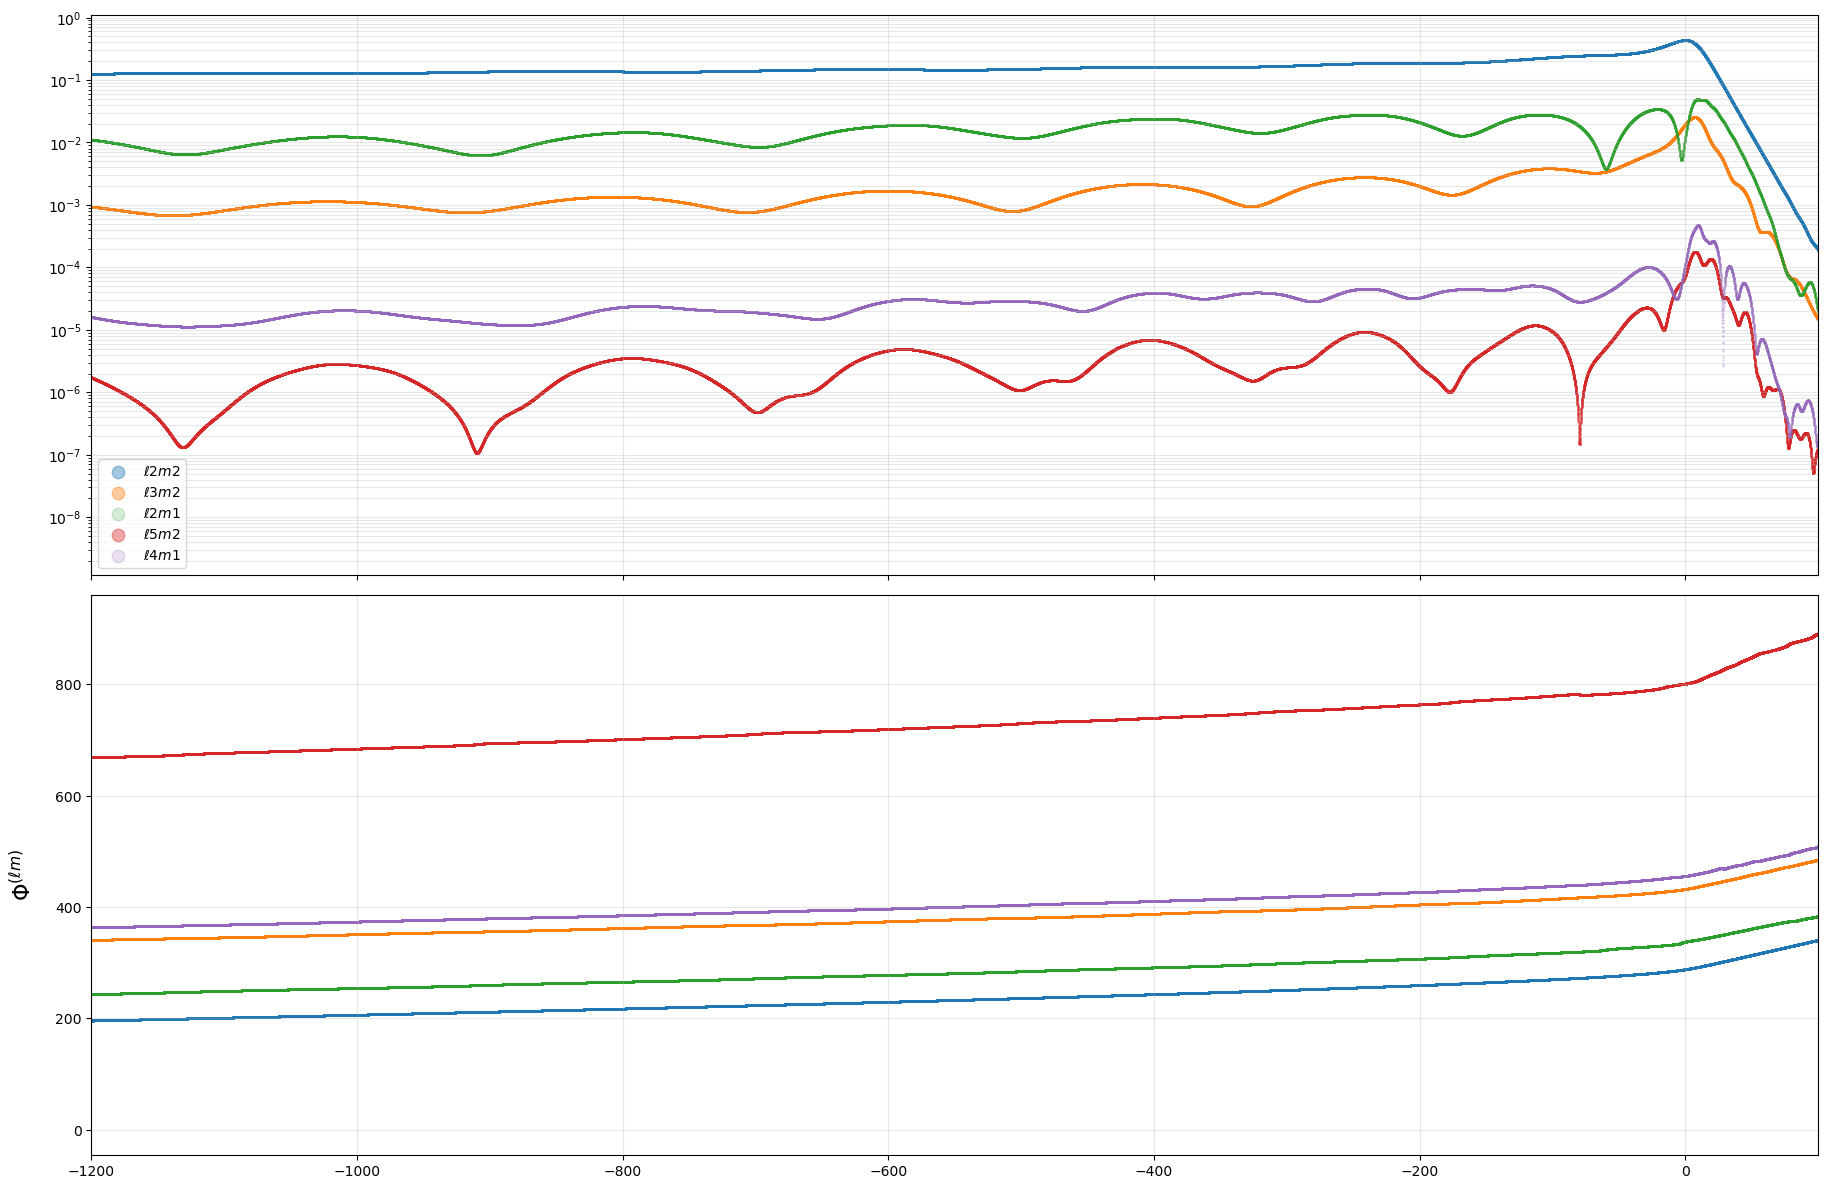

In [144]:
wfm.plot_strongest_modes(nmodes=5)

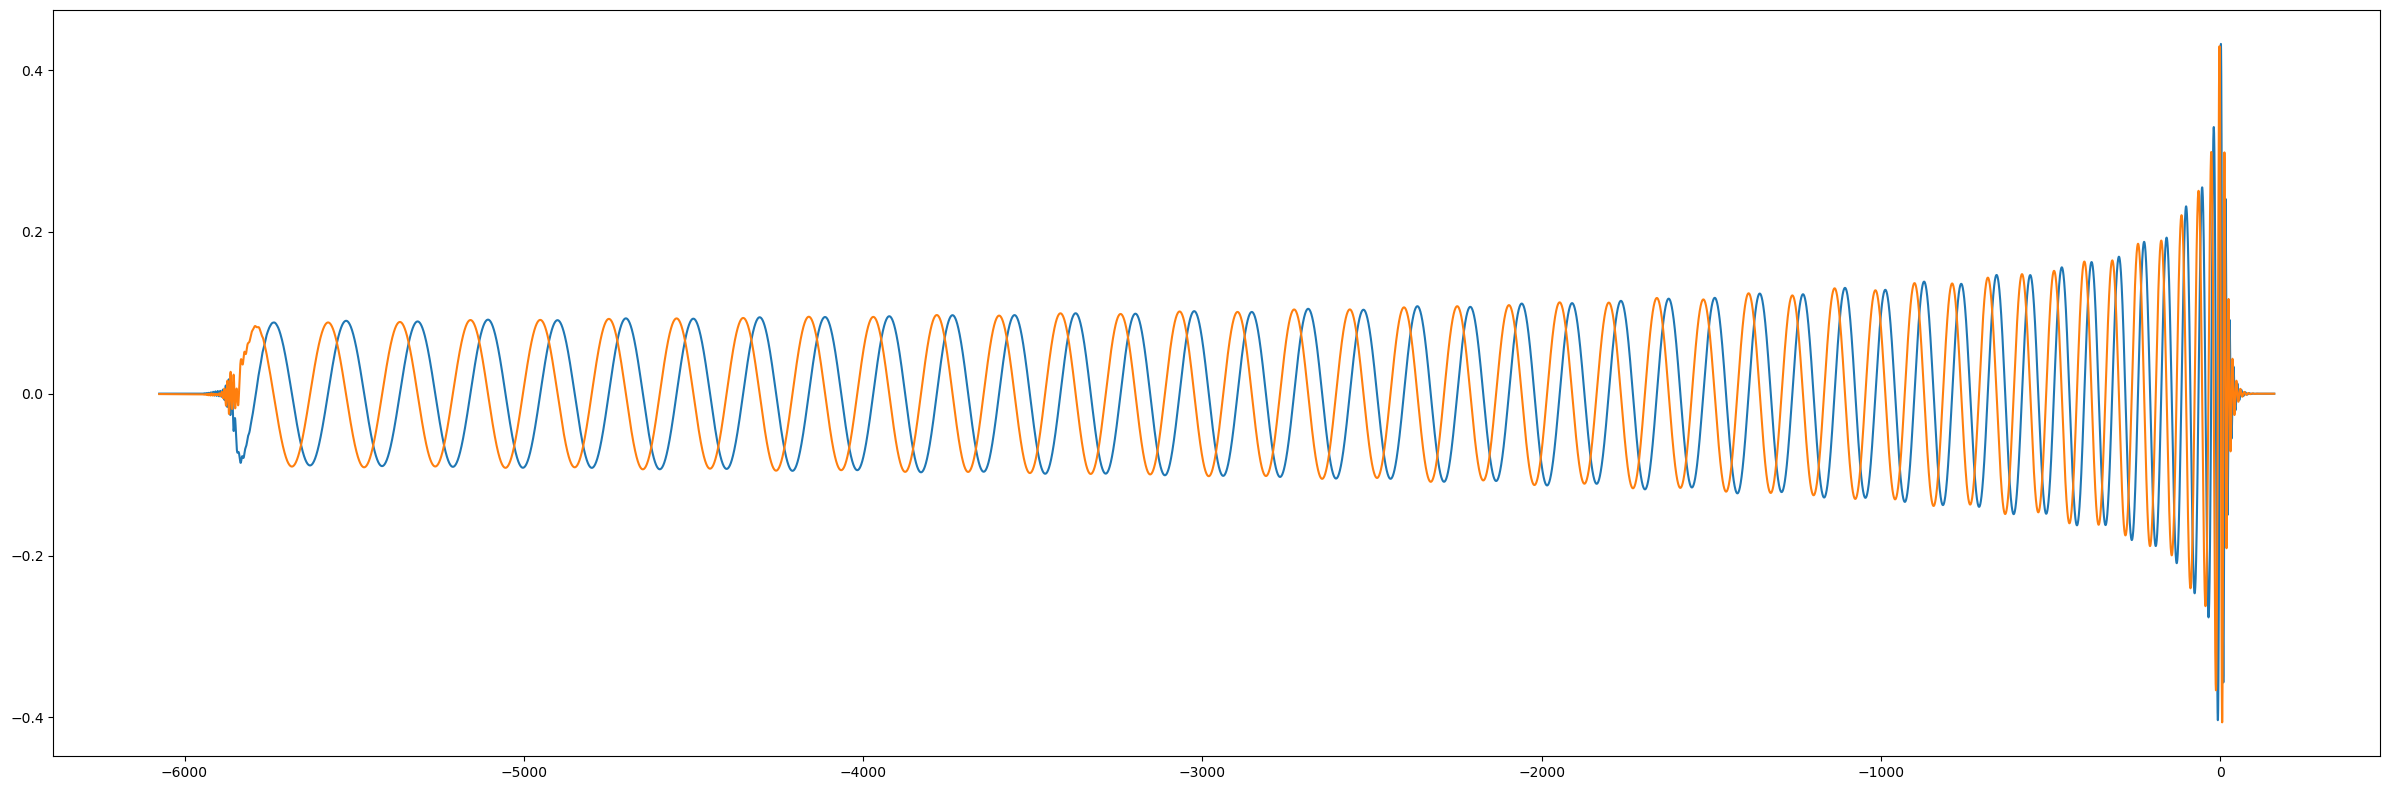

In [21]:
fig, ax = plt.subplots(figsize=(24, 8))

ax.plot(wfm.time_axis, wfm.mode(2, 2).real)
ax.plot(wfm.time_axis, wfm.mode(2, 2).imag)
plt.show()